First, we need to mount Google Drive to access its contents.

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Once Google Drive is mounted, you can change the current working directory to `Level_6_AI_`.

In [26]:
import os

# Define the path to your folder in Google Drive
folder_path = '/content/drive/MyDrive/Level_6_AI_'

# Change the current working directory
os.chdir(folder_path)

# Verify the current working directory
print(f"Current working directory: {os.getcwd()}")

Current working directory: /content/drive/MyDrive/Level_6_AI_


In [27]:
from PIL import Image
import numpy as np
import os




In [28]:
# Load the images from the folder structure
from PIL import Image
import numpy as np
import os

def load_images_from_folder(folder_path, img_size=(28, 28)):
    images = []
    labels = []

    class_names = sorted([
        d for d in os.listdir(folder_path)
        if os.path.isdir(os.path.join(folder_path, d))
    ])

    class_to_index = {class_name: idx for idx, class_name in enumerate(class_names)}
    print("Class mapping:", class_to_index)

    for class_name in class_names:
        class_path = os.path.join(folder_path, class_name)
        label = class_to_index[class_name]

        for file in os.listdir(class_path):
            img_path = os.path.join(class_path, file)

            try:
                img = Image.open(img_path).convert("L")
                img = img.resize(img_size)
                img_array = np.array(img)

                images.append(img_array)
                labels.append(label)

            except Exception as e:
                print(f"Skipping {img_path}: {e}")
                continue

    return np.array(images), np.array(labels)



X_train, y_train = load_images_from_folder('assets/devnagari_dataset/DevanagariHandwrittenDigitDataset/Train')
X_test, y_test = load_images_from_folder('assets/devnagari_dataset/DevanagariHandwrittenDigitDataset/Test')

Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}


In [29]:

# Normalize ( 0-255 -> 0 - 1)

X_train = X_train / 255
X_test = X_test / 255


In [30]:
# Save these as numpy arrays cause it took too long
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

np.save("assets/devnagari_dataset/X_train.npy", X_train)
np.save("assets/devnagari_dataset/y_train.npy", y_train)
np.save("assets/devnagari_dataset/X_test.npy", X_test)
np.save("assets/devnagari_dataset/y_test.npy", y_test)

(17000, 28, 28) (17000,)
(3000, 28, 28) (3000,)


In [37]:


# Load saved numpy arrays
X_train = np.load("assets/devnagari_dataset/X_train.npy")
y_train = np.load("assets/devnagari_dataset/y_train.npy")

X_test = np.load("assets/devnagari_dataset/X_test.npy")
y_test = np.load("assets/devnagari_dataset/y_test.npy")

# Currently our data is in:
# (n_samples, 28,28) shape,
# Keras and other deep learning libraries expect it to be in:
# (n_samples, n_height, n_width, channels)
# so it wants, (n_samples, 28, 28, 1)

# keep the same number of samples (-1)

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)


print("After preprocessing:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

After preprocessing:
X_train: (17000, 28, 28, 1)
y_train: (17000,)
X_test: (3000, 28, 28, 1)
y_test: (3000,)


In [38]:
# So no wwe need to convert 28x28x1 into a flat vector of 784

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    # Flatten the 28,28,1 into 784
    Flatten(input_shape=(28,28,1)),

    # 64 neurons each neuron sees all 784 inputs
    Dense(64, activation='sigmoid'),

    # 128 neuron, 64 inputs
    Dense(128, activation='sigmoid'),

    # 256 neurons, 128 inputs
    Dense(256, activation='sigmoid'),

    # 10 neurons, 1 per class, softmax turns outputs into probabilities over 10 clases
    Dense(10, activation='softmax')

])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [54]:
'''

- Epochs = 20, training set 20 times
- batch size: trains on 128 images at a time
- validation_split: hold out 20% of training data for validation

'''
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

from sklearn.utils import shuffle
X_train, y_train = shuffle(X_train, y_train, random_state=42)


X_train: (17000, 28, 28, 1)
y_train: (17000,)
X_test: (3000, 28, 28, 1)
y_test: (3000,)


In [56]:
history = model.fit(X_train, y_train, epochs=20, batch_size=128, validation_split=0.2)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.9557 - loss: 0.2081 - val_accuracy: 0.9888 - val_loss: 0.0382
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9940 - loss: 0.0221 - val_accuracy: 0.9874 - val_loss: 0.0349
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9982 - loss: 0.0100 - val_accuracy: 0.9915 - val_loss: 0.0288
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9992 - loss: 0.0054 - val_accuracy: 0.9909 - val_loss: 0.0267
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9999 - loss: 0.0033 - val_accuracy: 0.9938 - val_loss: 0.0263
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9999 - loss: 0.0020 - val_accuracy: 0.9932 - val_loss: 0.0252
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9999 - loss: 0.0015 - val_accuracy: 0.9938 - val_loss: 0.0248
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9999 - loss: 0.0012 - val_accuracy: 

In [57]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9830 - loss: 0.0844
Test loss: 0.08436671644449234
Test accuracy: 0.9829999804496765


In [58]:
# Trying out relu

model = Sequential([
    # Flatten the 28,28,1 into 784
    Flatten(input_shape=(28,28,1)),

    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')

])

model.summary()


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(X_train, y_train, epochs=20, batch_size=128, validation_split=0.2)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8523 - loss: 0.5032 - val_accuracy: 0.9291 - val_loss: 0.2272
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9579 - loss: 0.1480 - val_accuracy: 0.9541 - val_loss: 0.1574
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9724 - loss: 0.0982 - val_accuracy: 0.9676 - val_loss: 0.1213
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9809 - loss: 0.0675 - val_accuracy: 0.9638 - val_loss: 0.1174
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9876 - loss: 0.0473 - val_accuracy: 0.9676 - val_loss: 0.1074
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9921 - loss: 0.0352 - val_accuracy: 0.9700 - val_loss: 0.1058
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9937 - loss: 0.0272 - val_accuracy: 0.9750 - val_loss: 0.0925
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9968 - loss: 0.0194 - val_accuracy: 0.

In [59]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9847 - loss: 0.0706
Test loss: 0.07064853608608246
Test accuracy: 0.984666645526886


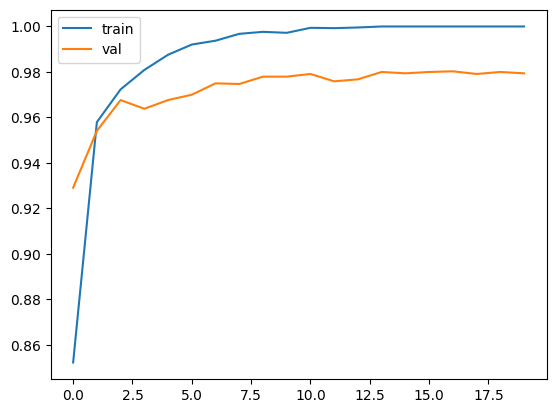

In [60]:
import matplotlib.pyplot as plt

# plot
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()

# save model
model.save("week4_fcn.keras")